2025-01-30 21:21:24: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-30 21:21:24: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-30 21:21:24: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-01-30 21:21:24: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-01-30 21:21:24: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-01-30 21:21:24: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2025-01-30 21:21:25: oggm.cfg: PARAMS['temp_melt'] changed from `-1.0` to `-1.83`.


Comparison with Pálsson data:
Original model - Mean bias: 1431.4 kg m-2, MBE: 1431.4 kg m-2
Modified model - Mean bias: -916.6 kg m-2, MBE: -916.6 kg m-2


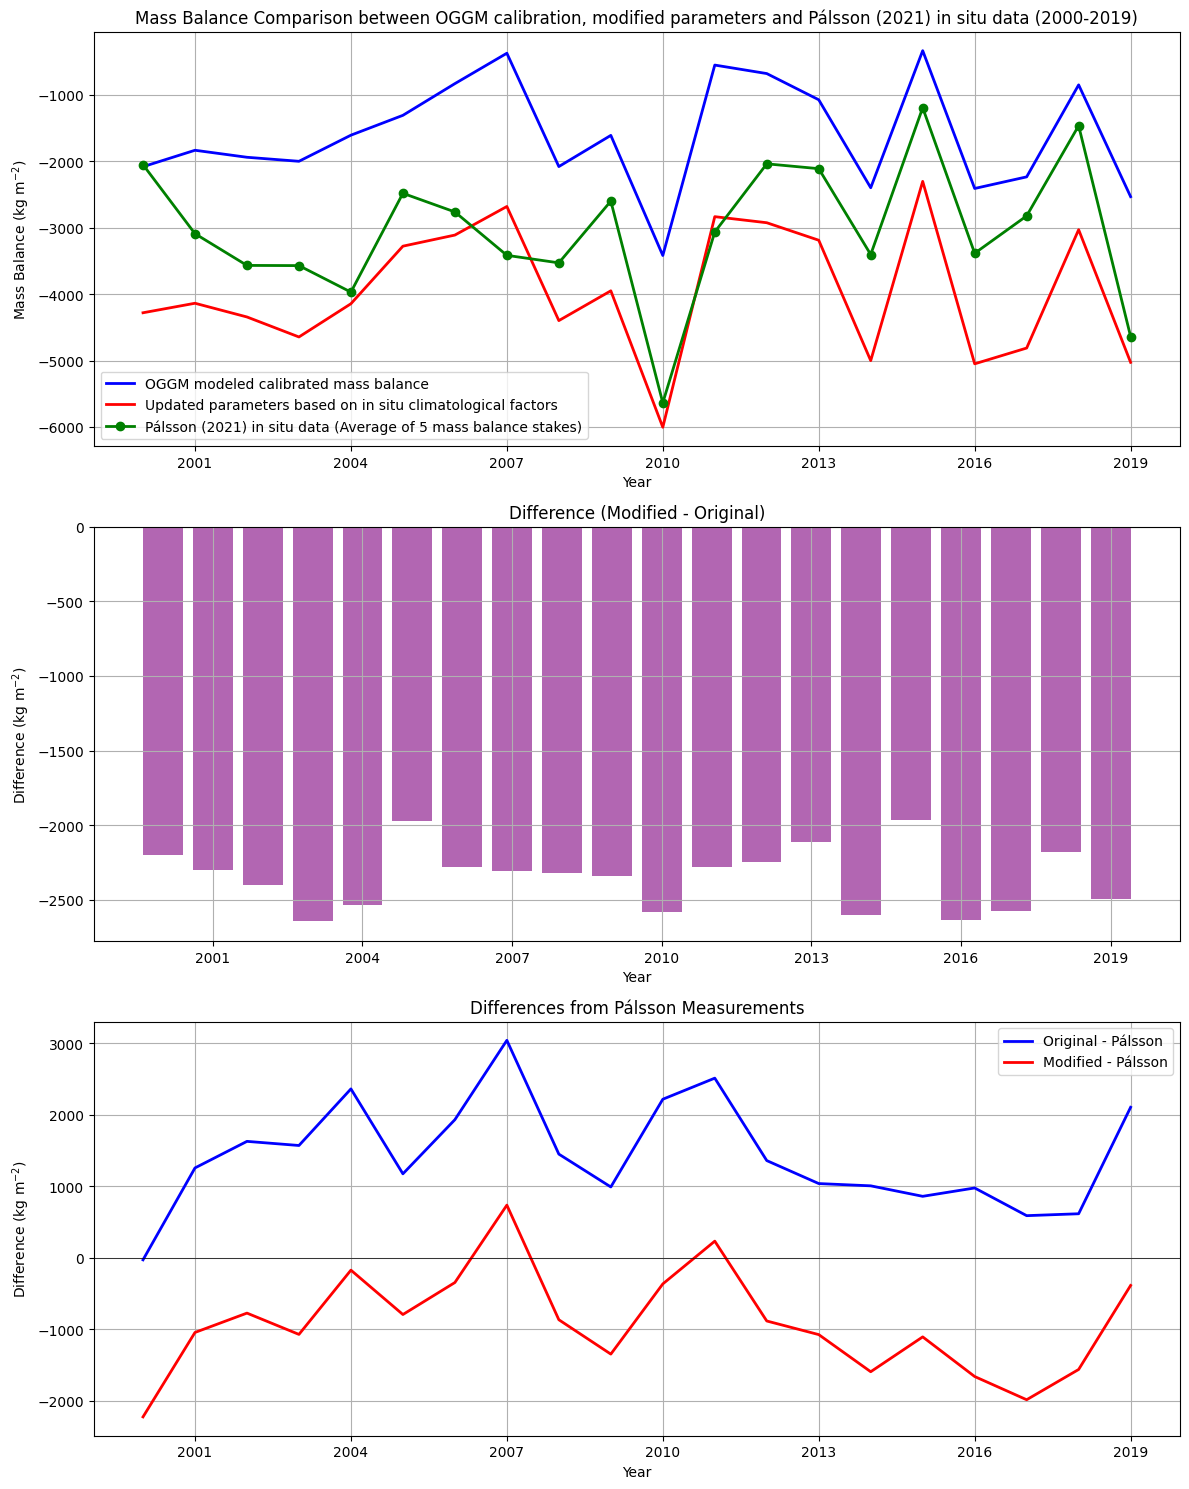


Correlation with Pálsson data:
Original model: 0.702
Modified model: 0.743

Mean Mass Balance:
OGGM modeled calibrated mass balance: -1610.5 kg m-2
Updated parameters based on in situ climatological factors: -3958.5 kg m-2
Pálsson data (Average of 5 mass balance stakes): -3041.9 kg m-2


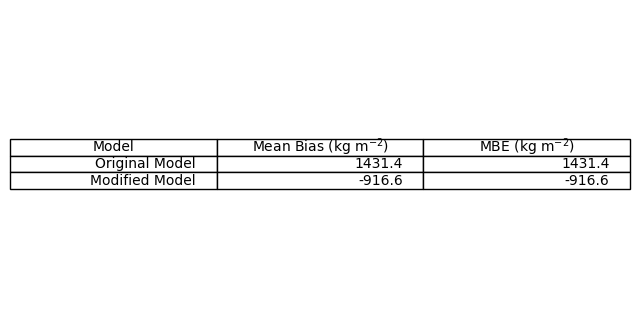

2025-01-30 21:21:25: oggm.cfg: PARAMS['temp_melt'] changed from `-1.83` to `-1.0`.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import oggm
from oggm import cfg, utils, workflow, graphics
from oggm.core import massbalance
from matplotlib.ticker import MaxNLocator  # For controlling x-axis ticks

# Initialize OGGM and set up the working directory
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-mb', reset=True)
cfg.PARAMS['border'] = 10

# Load preprocessed glacier directories
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5/'
gdirs = workflow.init_glacier_directories(['RGI60-06.00291'], from_prepro_level=3, prepro_base_url=base_url)
gdir_kwf = gdirs[0]

# Read the original mass balance calibration parameters
mb_calib = gdir_kwf.read_json('mb_calib')

# Store original temp_melt
original_temp_melt = cfg.PARAMS['temp_melt']

# Calculate with original parameters
original_params = {
    'melt_f': mb_calib['melt_f'],
    'temp_bias': mb_calib['temp_bias'],
    'prcp_fac': mb_calib['prcp_fac']
}

mbmod_original = massbalance.MonthlyTIModel(gdir_kwf, check_calib_params=False, **original_params)
h, w = gdir_kwf.get_inversion_flowline_hw()
years = np.arange(2000, 2020, 1)  # Adjusted to 2000-2019 (no fractional years)
mbdf = pd.DataFrame(index=years)
mbdf['original_mb'] = mbmod_original.get_specific_mb(h, w, year=mbdf.index)

# Modify global temp_melt and calculate with new parameters
cfg.PARAMS['temp_melt'] = -1.83

modified_params = {
    'melt_f': 6.6,
    'temp_bias': mb_calib['temp_bias'],
    'prcp_fac': mb_calib['prcp_fac']
}

mbmod_modified = massbalance.MonthlyTIModel(gdir_kwf, check_calib_params=False, **modified_params)
mbdf['modified_mb'] = mbmod_modified.get_specific_mb(h, w, year=mbdf.index)

# Add Pálsson in situ measurements (only up to 2019)
palsson_data = [-2054, -3092.2, -3569.4, -3572.2, -3971, -2484.4, -2765, -3417.8, 
                -3531, -2602.2, -5636.2, -3066.8, -2041.2, -2114, -3405.8, -1196.8,
                -3386.8, -2824.8, -1467.6, -4639]
mbdf['palsson_mb'] = palsson_data

# Calculate differences with Pálsson data
mbdf['diff_original_palsson'] = mbdf['original_mb'] - mbdf['palsson_mb']
mbdf['diff_modified_palsson'] = mbdf['modified_mb'] - mbdf['palsson_mb']

# Calculate mean bias
bias_original = np.mean(mbdf['diff_original_palsson'])
bias_modified = np.mean(mbdf['diff_modified_palsson'])

# Calculate MBE (Mean Bias Error)
mbe_original = np.mean(mbdf['diff_original_palsson'])
mbe_modified = np.mean(mbdf['diff_modified_palsson'])

# Print statistics
print(f"Comparison with Pálsson data:")
print(f"Original model - Mean bias: {bias_original:.1f} kg m-2, MBE: {mbe_original:.1f} kg m-2")
print(f"Modified model - Mean bias: {bias_modified:.1f} kg m-2, MBE: {mbe_modified:.1f} kg m-2")

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# Plot mass balances
ax1.plot(mbdf.index, mbdf['original_mb'], label='OGGM modeled calibrated mass balance', color='blue', lw=2)
ax1.plot(mbdf.index, mbdf['modified_mb'], label='Updated parameters based on in situ climatological factors', color='red', lw=2)
ax1.plot(mbdf.index, mbdf['palsson_mb'], label='Pálsson (2021) in situ data (Average of 5 mass balance stakes)', color='green', lw=2, marker='o')
ax1.set_xlabel('Year')
ax1.set_ylabel('Mass Balance (kg m$^{-2}$)')
ax1.set_title('Mass Balance Comparison between OGGM calibration, modified parameters and Pálsson (2021) in situ data (2000-2019)')
ax1.grid(True)
ax1.legend()

# Ensure integer ticks on x-axis
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# Plot differences between models
ax2.bar(mbdf.index, mbdf['modified_mb'] - mbdf['original_mb'], color='purple', alpha=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Year')
ax2.set_ylabel('Difference (kg m$^{-2}$)')
ax2.set_title('Difference (Modified - Original)')
ax2.grid(True)

# Ensure integer ticks on x-axis for second plot
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

# Plot differences with Pálsson data
ax3.plot(mbdf.index, mbdf['diff_original_palsson'], label='Original - Pálsson', color='blue', lw=2)
ax3.plot(mbdf.index, mbdf['diff_modified_palsson'], label='Modified - Pálsson', color='red', lw=2)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Year')
ax3.set_ylabel('Difference (kg m$^{-2}$)')
ax3.set_title('Differences from Pálsson Measurements')
ax3.grid(True)
ax3.legend()

# Ensure integer ticks on x-axis for third plot
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Additional statistics
print("\nCorrelation with Pálsson data:")
print(f"Original model: {mbdf['original_mb'].corr(mbdf['palsson_mb']):.3f}")
print(f"Modified model: {mbdf['modified_mb'].corr(mbdf['palsson_mb']):.3f}")

# Print mean values
print("\nMean Mass Balance:")
print(f"OGGM modeled calibrated mass balance: {mbdf['original_mb'].mean():.1f} kg m-2")
print(f"Updated parameters based on in situ climatological factors: {mbdf['modified_mb'].mean():.1f} kg m-2")
print(f"Pálsson data (Average of 5 mass balance stakes): {mbdf['palsson_mb'].mean():.1f} kg m-2")

# Create table of additional statistics
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('tight')
ax.axis('off')
table_data = [["Original Model", f"{bias_original:.1f}", f"{mbe_original:.1f}"],
              ["Modified Model", f"{bias_modified:.1f}", f"{mbe_modified:.1f}"]]
table = ax.table(cellText=table_data, colLabels=["Model", "Mean Bias (kg m$^{-2}$)", "MBE (kg m$^{-2}$)"], loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
plt.show()

# Restore original temp_melt
cfg.PARAMS['temp_melt'] = original_temp_melt
